# Prototipo de detección de daños vehiculares — Demostración de avances

**TT2 · ESCOM–IPN** · Detección de daños nuevos (golpes, fisuras, rayones) comparando
la imagen de un vehículo *antes* y *después* de una renta.

Este notebook recorre los tres módulos de la arquitectura propuesta y muestra el estado
real de cada uno sobre imágenes que **ninguno de los dos modelos vio durante el
entrenamiento**.

| Módulo | Contenido | Estado |
|---|---|---|
| **1. Preprocesamiento óptico** | Normalización (CLAHE) y eliminación de reflejos especulares | Implementado — *demostrativo* |
| **2. Segmentación** | Detección de 47 componentes del vehículo (Faster R-CNN) | Entrenado — `car_parts/v1` |
| **2b. Detección de daños** | 6 tipos de daño con máscara (Mask R-CNN) | Entrenado — `damage/v1` |
| **3. Detección de cambios** | Comparación antes/después | **Pendiente** |

> **Nota de alcance.** El Módulo 1 se presenta únicamente como demostración visual.
> Sus salidas **no** alimentan a los módulos 2 y 3: ambos detectores fueron entrenados
> sobre píxeles sin normalizar, así que aplicarles CLAHE o supresión de brillos sólo en
> inferencia introduciría un desajuste entre entrenamiento e inferencia, y las métricas
> reportadas en el documento dejarían de corresponder. Los detectores reciben la
> **imagen original**.

---
## 0. Configuración

In [1]:
import os
import sys

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from IPython.display import Markdown, display

# Jupyter arranca con cwd = notebooks/, el resto del proyecto se resuelve desde la raíz.
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.preprocessing.normalization import apply_clahe_rgb, resize_with_padding
from src.preprocessing.specular_removal import ShenParams, remove_specular_highlights, specular_map
from src.detection.common.predict import load_checkpoint
from src.detection.common.visualize import draw_detections

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEMO_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "final_test")

# Caso A: acercamiento al daño.  Caso B: vehículo completo.
CASO_A = os.path.join(DEMO_DIR, "car-test.jpg")
CASO_B = os.path.join(DEMO_DIR, "car-test4.jpg")

plt.rcParams["figure.dpi"] = 110

print("Raiz del proyecto :", PROJECT_ROOT)
print("Dispositivo       :", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

Raiz del proyecto : C:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos
Dispositivo       : cuda NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
def load_image(path, min_side=900):
    """Carga una imagen BGR y la escala a un tamaño cómodo para visualizar."""
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError("No se pudo leer: " + path)
    h, w = image.shape[:2]
    if max(h, w) < min_side:
        scale = min_side / max(h, w)
        image = cv2.resize(image, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)
    return image


def show(panels, height=4.6, title=None):
    """Dibuja una fila de paneles ``(titulo, imagen)``; acepta BGR o escala de grises."""
    fig, axes = plt.subplots(1, len(panels), figsize=(height * len(panels) * 1.35, height))
    axes = np.atleast_1d(axes)
    for ax, (caption, image) in zip(axes, panels):
        if image.ndim == 2:
            ax.imshow(image, cmap="inferno")
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(caption, fontsize=10)
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()


def tabla(encabezados, filas):
    """Renderiza una tabla Markdown (el entorno no tiene pandas instalado)."""
    linea = lambda vals: "| " + " | ".join(str(v) for v in vals) + " |"
    cuerpo = [linea(encabezados), linea(["---"] * len(encabezados))] + [linea(f) for f in filas]
    display(Markdown("\n".join(cuerpo)))

---
# Módulo 1 — Preprocesamiento óptico

Su objetivo es dejar la imagen en condiciones comparables antes de analizarla: mismo
rango dinámico, mismo tamaño, y sin los reflejos especulares que la pintura automotriz
genera bajo luz directa y que un detector puede confundir con un rayón.

## 1.1 Normalización

`apply_clahe_rgb()` aplica **CLAHE** (ecualización adaptativa de histograma con límite de
contraste) sobre el canal de luminancia *L* del espacio **LAB**, no sobre RGB. Al tocar
sólo la luminancia se realza el micro-contraste —que es donde vive la evidencia de una
rayadura o el pliegue de una abolladura— **sin desplazar el color** de la carrocería.

`resize_with_padding()` lleva la imagen a un lienzo fijo de 512×512 conservando la
relación de aspecto y rellenando con negro, de modo que un auto fotografiado en vertical
y otro en horizontal no salgan deformados.

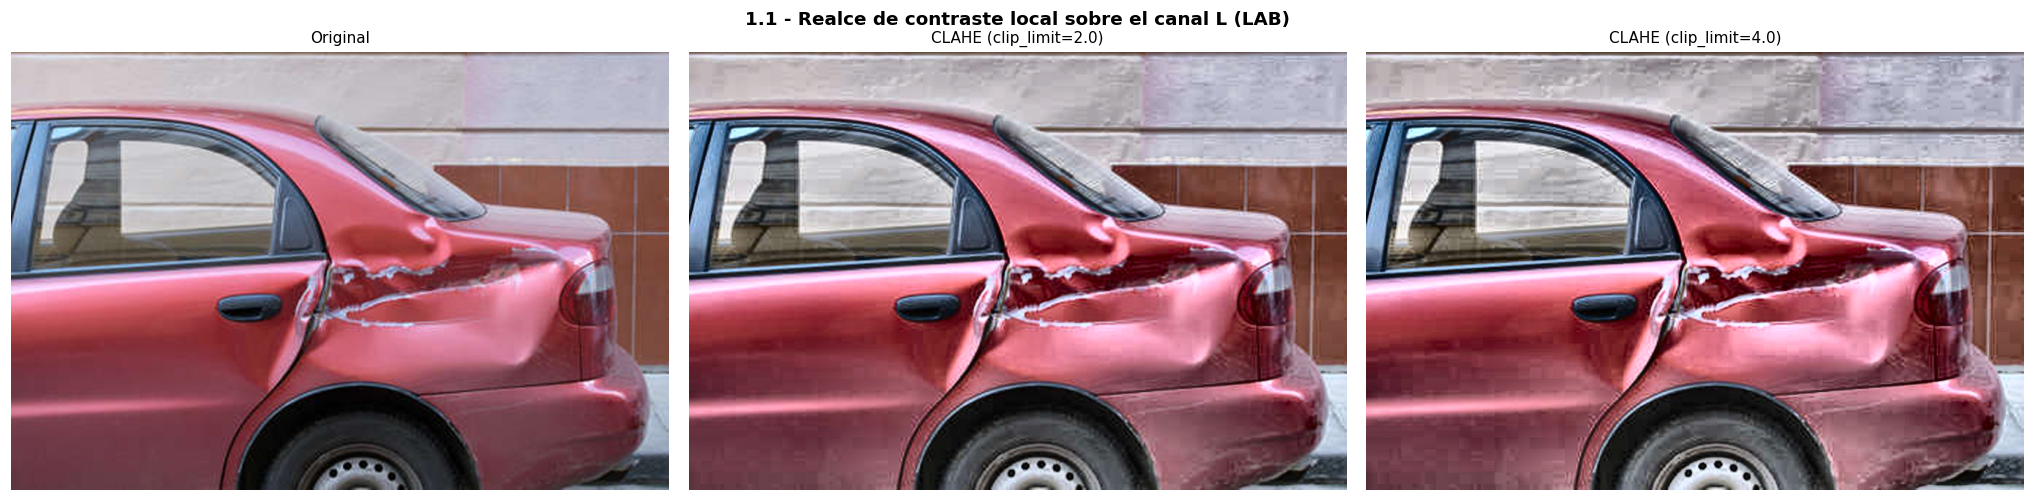

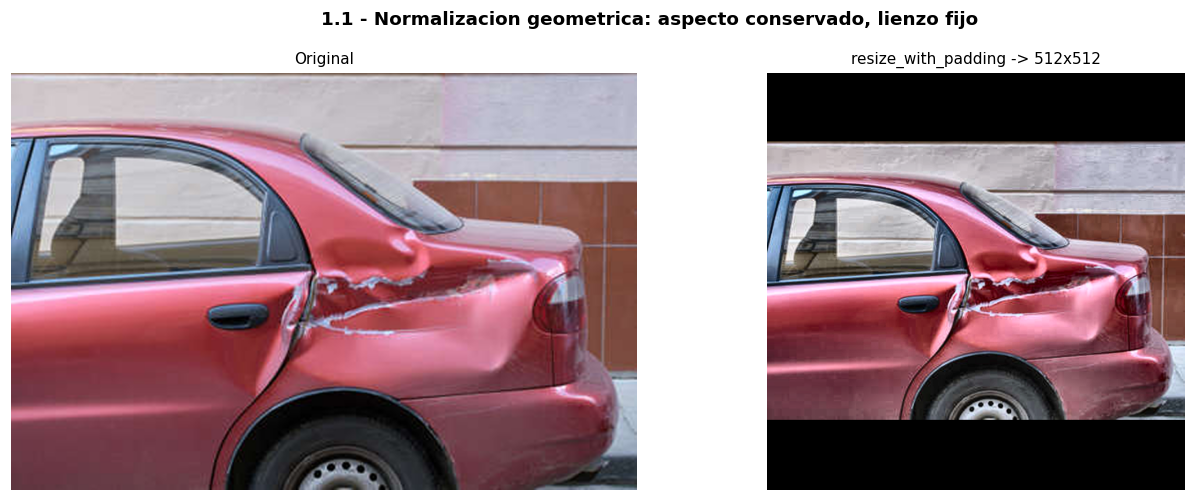

In [3]:
original_a = load_image(CASO_A)

clahe_suave  = apply_clahe_rgb(original_a, clip_limit=2.0)
clahe_fuerte = apply_clahe_rgb(original_a, clip_limit=4.0)

show([("Original", original_a),
      ("CLAHE (clip_limit=2.0)", clahe_suave),
      ("CLAHE (clip_limit=4.0)", clahe_fuerte)],
     title="1.1 - Realce de contraste local sobre el canal L (LAB)")

show([("Original", original_a),
      ("resize_with_padding -> 512x512", resize_with_padding(clahe_suave, (512, 512)))],
     title="1.1 - Normalizacion geometrica: aspecto conservado, lienzo fijo")

### Lectura del resultado

Con `clip_limit=2.0` el pliegue de la abolladura y la raspadura de pintura ganan
definición sin que aparezca ruido. Con `clip_limit=4.0` se aprecia el efecto secundario
que hay que evitar: el contraste local se exagera, la textura del muro del fondo empieza
a competir visualmente con el daño y aparece grano en las zonas de sombra. **2.0 es el
valor de trabajo.**

## 1.2 Eliminación de reflejos especulares

Implementa el método **no iterativo de máxima cromaticidad difusa** de *Shen & Cai
(2009)*, basado en el **modelo de reflexión dicromática**: la intensidad observada se
descompone en una componente **difusa** (el color propio de la superficie) y una
componente **especular** (el reflejo de la fuente de luz, acromático). Estimando la
cromaticidad máxima difusa por píxel se despeja en forma cerrada cuánta intensidad
especular retirar.

Sobre el método original se añadió una **compuerta de brillo** (`brightness_threshold`,
`brightness_softness`) que no está en el artículo. La razón es concreta: el método puro
no puede distinguir un brillo especular de una superficie difusa naturalmente gris o
negra —llantas, asfalto, sombras— porque ambas tienen cromaticidad cercana a 1/3, y
termina oscureciéndolas. La compuerta restringe la corrección a los píxeles realmente
brillantes y mezcla suavemente hacia el original en el resto.

ShenParams(epsilon=1e-06, smooth_ksize=3, diffuse_chromaticity_clip=0.35, brightness_threshold=180.0, brightness_softness=40.0)


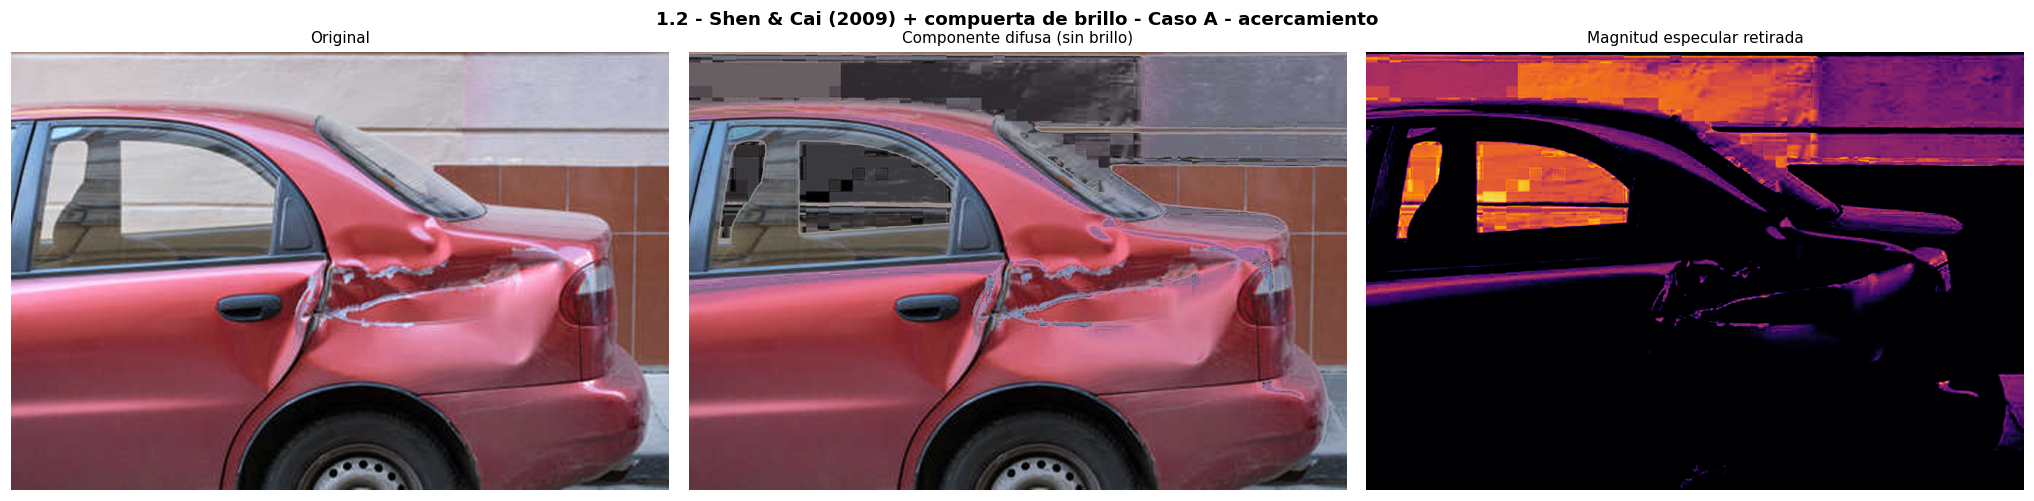

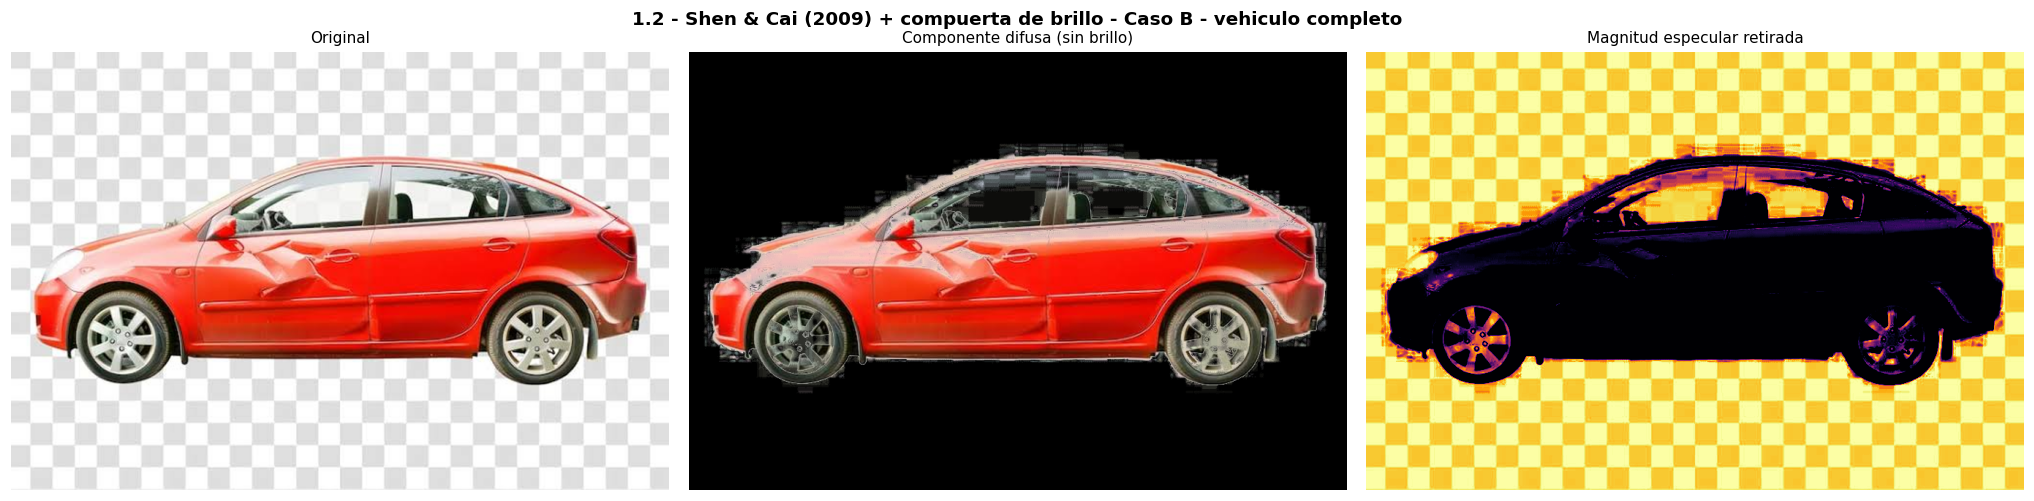

In [4]:
params = ShenParams()   # epsilon=1e-6, smooth_ksize=3, clip=0.35, umbral=180.0, suavidad=40.0
print(params)

for etiqueta, ruta in [("Caso A - acercamiento", CASO_A), ("Caso B - vehiculo completo", CASO_B)]:
    imagen = load_image(ruta)
    difusa = remove_specular_highlights(imagen, params)
    mapa = specular_map(imagen, difusa)
    show([("Original", imagen),
          ("Componente difusa (sin brillo)", difusa),
          ("Magnitud especular retirada", mapa)],
         title="1.2 - Shen & Cai (2009) + compuerta de brillo - " + etiqueta)

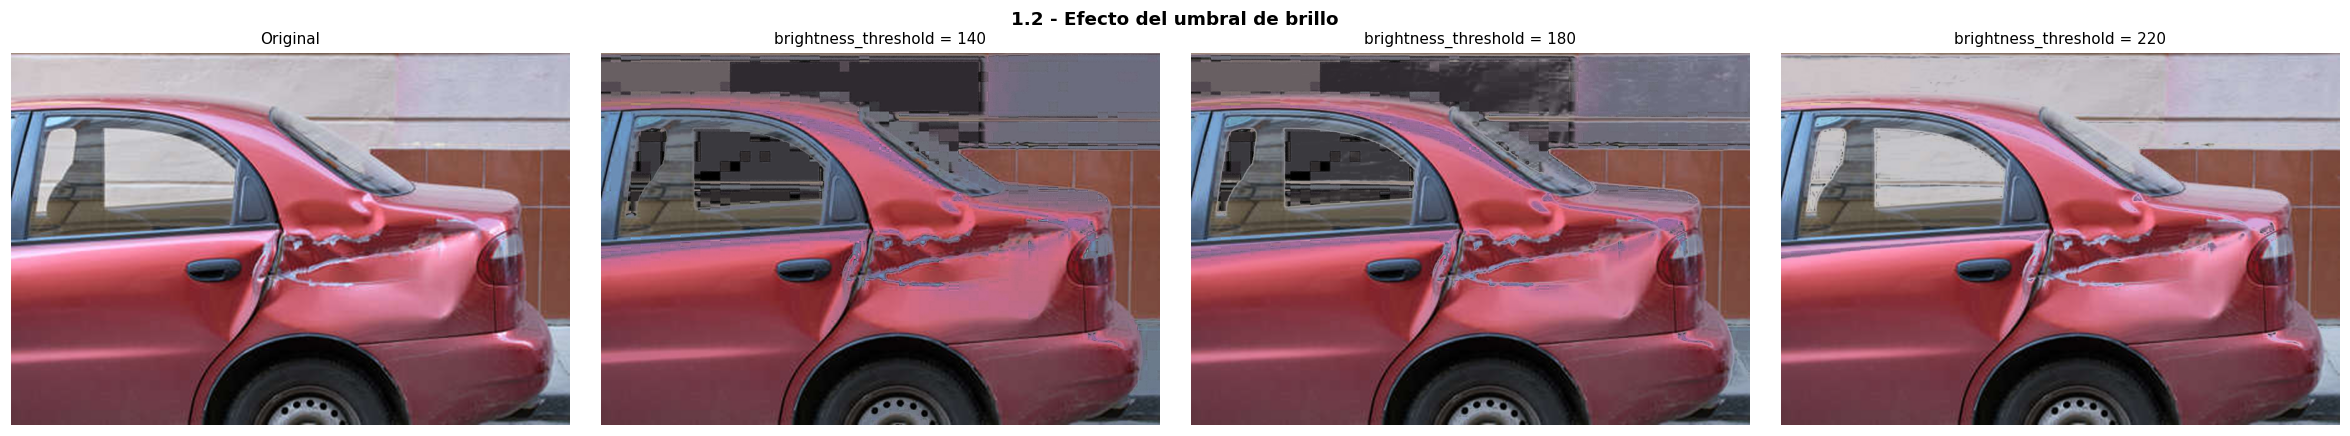

In [5]:
# Sensibilidad al umbral de brillo: es el parametro que decide que se considera reflejo.
imagen = load_image(CASO_A)
paneles = [("Original", imagen)]
for umbral in (140.0, 180.0, 220.0):
    difusa = remove_specular_highlights(imagen, ShenParams(brightness_threshold=umbral))
    paneles.append(("brightness_threshold = %.0f" % umbral, difusa))
show(paneles, height=4.0, title="1.2 - Efecto del umbral de brillo")

### Por qué el Módulo 1 se queda fuera del resto de la tubería

El barrido anterior muestra el problema abierto. Con el umbral bajo (140) el algoritmo
sí retira los reflejos, pero también **apaga zonas difusas legítimamente oscuras** —la
llanta, la sombra bajo el vehículo, el vidrio— porque no puede diferenciarlas de un
brillo. Con el umbral alto (220) preserva la imagen pero apenas corrige. No existe
todavía un ajuste que quite el reflejo sin degradar la carrocería, y en una imagen con
daño real esa degradación puede **borrar la evidencia que el detector necesita**.

Por eso, en esta demostración el Módulo 1 es **exclusivamente ilustrativo**. Los módulos
2 y 3 que siguen reciben la **imagen original sin procesar**. Integrarlo exige antes:

1. sustituir la compuerta global de brillo por una **máscara de carrocería** (que el
   Módulo 2 ya puede proveer), para no tocar llantas, vidrios ni fondo; y
2. **reentrenar** los detectores sobre imágenes ya preprocesadas, porque hoy fueron
   entrenados sobre píxeles crudos y aplicar el preprocesamiento sólo en inferencia
   introduce un desajuste entre entrenamiento e inferencia.

---
# Módulo 2 — Segmentación de componentes y detección de daños

Dos detectores independientes, entrenados sobre conjuntos de datos distintos, corriendo
sobre la **misma imagen**:

| | Componentes | Daños |
|---|---|---|
| Arquitectura | Faster R-CNN ResNet50-FPN v2 | **Mask** R-CNN ResNet50-FPN v2 |
| Clases | 47 partes + fondo | 6 tipos de daño + fondo |
| Datos | *Car parts coco-segmentation* (333 imágenes) | **CarDD** (2 816 imágenes) |
| AP@0.5:0.95 (test) | **0.539** | caja **0.533** · máscara **0.495** |

Se usa Mask R-CNN para el daño porque un rayón es largo, delgado y casi siempre diagonal:
su caja delimitadora es mayoritariamente fondo, de modo que sólo la máscara localiza el
daño con precisión suficiente para el reporte de confianza.

Los *checkpoints* son **auto-descriptivos** —guardan `arch`, `num_classes` y
`categories`— así que `load_checkpoint()` reconstruye la arquitectura correcta sin que
haya que indicársela.

In [6]:
PARTS_CKPT  = os.path.join(PROJECT_ROOT, "models", "checkpoints", "car_parts", "v1", "best_model.pth")
DAMAGE_CKPT = os.path.join(PROJECT_ROOT, "models", "checkpoints", "damage",    "v1", "best_model.pth")

parts_model,  PART_NAMES   = load_checkpoint(PARTS_CKPT,  DEVICE)
damage_model, DAMAGE_NAMES = load_checkpoint(DAMAGE_CKPT, DEVICE)

print("Componentes : %d clases - %.1f M parametros"
      % (len(PART_NAMES), sum(p.numel() for p in parts_model.parameters()) / 1e6))
print("Danos       : %d clases -> %s" % (len(DAMAGE_NAMES), list(DAMAGE_NAMES.values())))

Componentes : 47 clases - 43.5 M parametros
Danos       : 6 clases -> ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


In [7]:
@torch.no_grad()
def predict(model, image_bgr, score_threshold):
    """Corre un detector sobre una imagen BGR y filtra por confianza."""
    tensor = TF.to_tensor(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)).to(DEVICE)
    output = model([tensor])[0]
    keep = output["scores"] >= score_threshold
    return {
        "boxes":  output["boxes"][keep].cpu().numpy(),
        "labels": output["labels"][keep].cpu().numpy(),
        "scores": output["scores"][keep].cpu().numpy(),
        "masks":  output["masks"][keep].cpu().numpy() if "masks" in output else None,
    }


def overlay(image_bgr, det, names):
    return draw_detections(image_bgr.copy(), det["boxes"], det["labels"],
                           det["scores"], names, masks=det["masks"])


def listar(det, names, top=12):
    orden = np.argsort(-det["scores"])[:top]
    return [(names.get(int(det["labels"][i]), "?"), round(float(det["scores"][i]), 2)) for i in orden]

---
## Caso A — Acercamiento al daño

Costado trasero de un sedán con una abolladura profunda y raspadura de pintura.
Es el encuadre típico de un peritaje: la cámara se acerca al golpe.

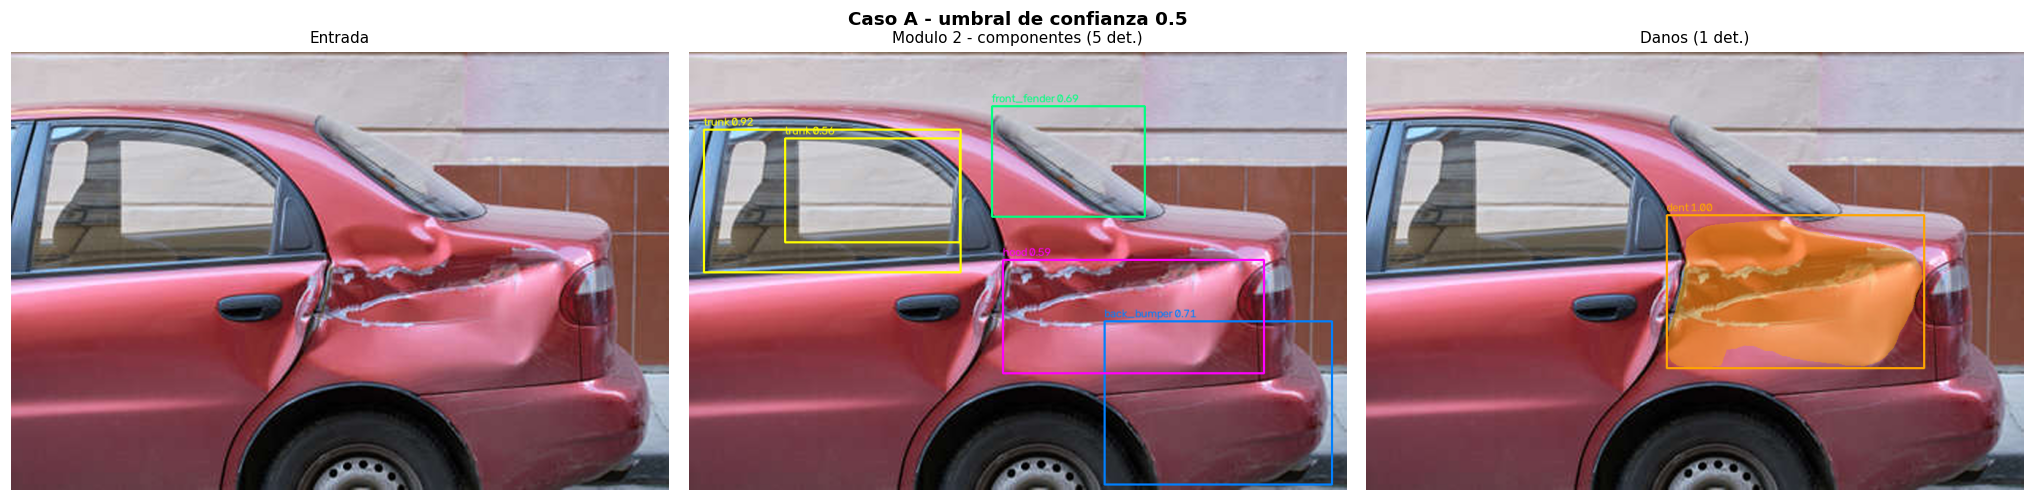

Componentes : [('trunk', 0.92), ('back_bumper', 0.71), ('front_fender', 0.69), ('hood', 0.59), ('trunk', 0.56)]
Danos       : [('dent', 1.0)]


In [8]:
imagen_a = load_image(CASO_A)
partes_a = predict(parts_model,  imagen_a, score_threshold=0.5)
danos_a  = predict(damage_model, imagen_a, score_threshold=0.5)

show([("Entrada", imagen_a),
      ("Modulo 2 - componentes (%d det.)" % len(partes_a["boxes"]), overlay(imagen_a, partes_a, PART_NAMES)),
      ("Danos (%d det.)" % len(danos_a["boxes"]), overlay(imagen_a, danos_a, DAMAGE_NAMES))],
     title="Caso A - umbral de confianza 0.5")

print("Componentes :", listar(partes_a, PART_NAMES))
print("Danos       :", listar(danos_a, DAMAGE_NAMES))

### Lectura del Caso A

**Detección de daños: correcta y con alta confianza.** Identifica `dent` con puntuación
**1.00** y la máscara sigue el pliegue de la lámina con precisión, incluyendo la
raspadura de pintura. Es exactamente el comportamiento buscado.

**Segmentación de componentes: falla.** Produce pocas cajas y con etiquetas equivocadas
—marca `trunk` sobre la ventanilla trasera y `hood` justo encima del golpe, en una
fotografía que es puro costado trasero. La causa se analiza más abajo; **no** es un
*checkpoint* dañado.

---
## Caso B — Vehículo completo

El encuadre opuesto: el auto entero en vista de perfil, con una abolladura en la puerta
delantera. Es el encuadre típico de la fotografía de entrega y devolución de una renta.

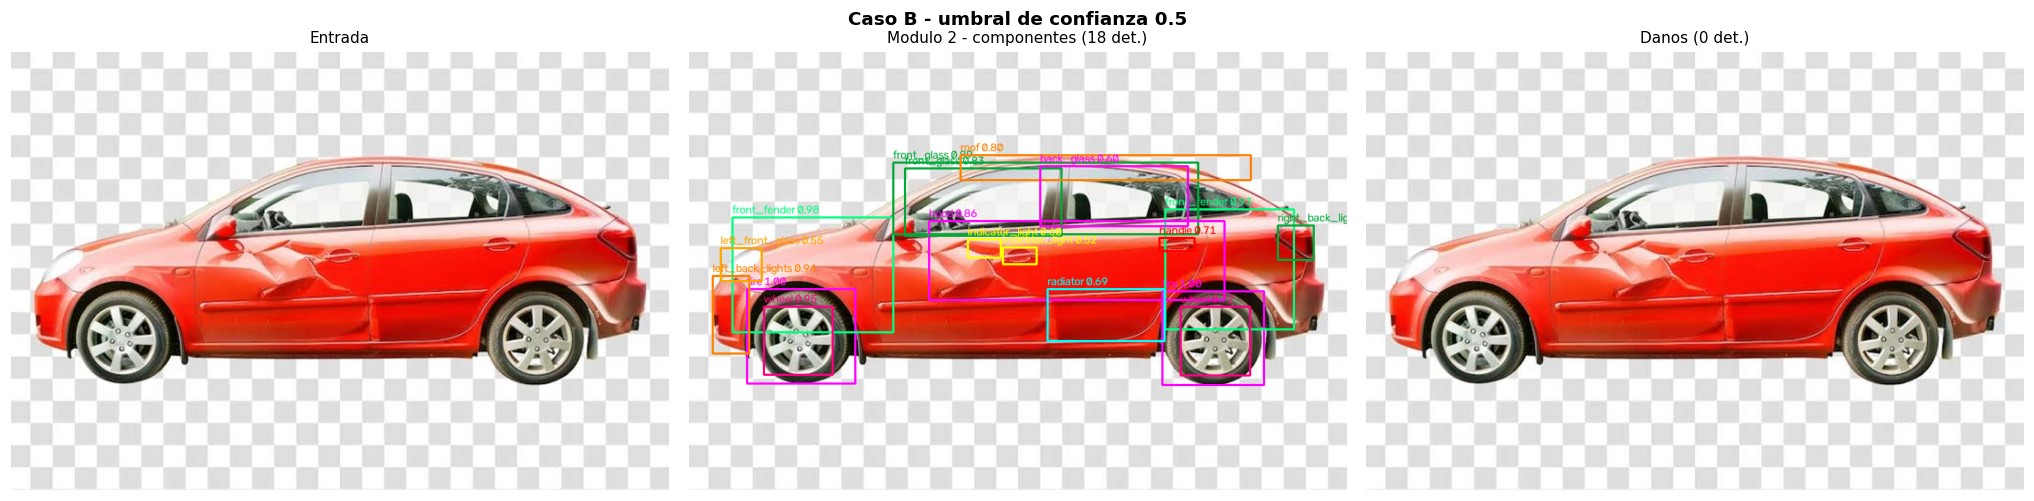

Componentes : [('tire', 1.0), ('tire', 1.0), ('front_fender', 0.98), ('wheel', 0.95), ('left_back_lights', 0.94), ('front_fender', 0.93), ('front_glass', 0.89), ('hood', 0.86), ('front_glass', 0.83), ('roof', 0.8), ('wheel', 0.72), ('handle', 0.71)]
Danos       : []


In [9]:
imagen_b = load_image(CASO_B)
partes_b = predict(parts_model,  imagen_b, score_threshold=0.5)
danos_b  = predict(damage_model, imagen_b, score_threshold=0.5)

show([("Entrada", imagen_b),
      ("Modulo 2 - componentes (%d det.)" % len(partes_b["boxes"]), overlay(imagen_b, partes_b, PART_NAMES)),
      ("Danos (%d det.)" % len(danos_b["boxes"]), overlay(imagen_b, danos_b, DAMAGE_NAMES))],
     title="Caso B - umbral de confianza 0.5")

print("Componentes :", listar(partes_b, PART_NAMES))
print("Danos       :", listar(danos_b, DAMAGE_NAMES))

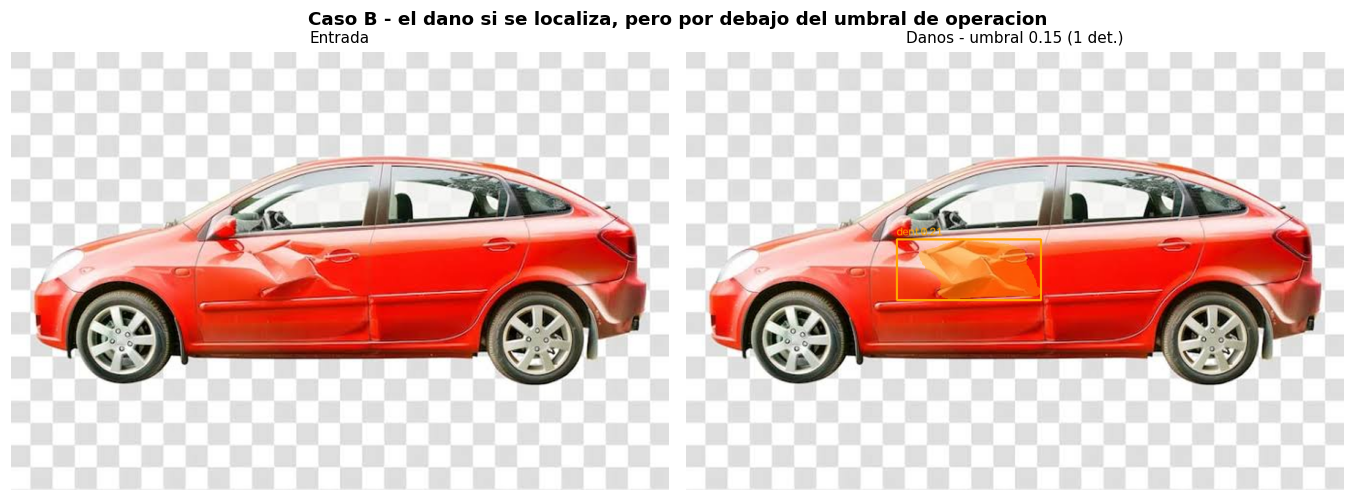

Danos : [('dent', 0.21)]


In [10]:
# A 0.5 el detector de danos no reporta nada. Bajando el umbral aparece el golpe.
UMBRAL_B = 0.15
danos_b = predict(damage_model, imagen_b, score_threshold=UMBRAL_B)

show([("Entrada", imagen_b),
      ("Danos - umbral %.2f (%d det.)" % (UMBRAL_B, len(danos_b["boxes"])),
       overlay(imagen_b, danos_b, DAMAGE_NAMES))],
     title="Caso B - el dano si se localiza, pero por debajo del umbral de operacion")

print("Danos :", listar(danos_b, DAMAGE_NAMES))

### Lectura del Caso B

Resultado **invertido** respecto al Caso A.

**Segmentación de componentes: funciona.** Recupera llantas, rines, cofre, techo,
cristales y manija con geometría coherente. Persiste un error de orientación —en una
vista de perfil puro confunde el frente con la parte trasera y equivoca el lado— pero el
módulo claramente está operando.

**Detección de daños: localiza bien, puntúa mal.** Con umbral 0.5 no reporta nada. Al
bajarlo, la máscara cae **exactamente sobre la puerta abollada**: la localización es
correcta, lo que falla es la *confianza*. Esto reproduce con precisión la debilidad
medida del modelo en el conjunto de prueba de CarDD: **AP en objetos pequeños 0.256**
frente a **AP en objetos grandes 0.539**. Al fotografiar el auto completo, el daño ocupa
una fracción pequeña del encuadre y cae en el régimen donde el modelo es débil.

---
## Cruce de módulos: ¿sobre qué componente está el daño?

Aquí es donde los dos módulos dejan de ser detectores independientes y se vuelven un
sistema. Para cada instancia de daño se calcula qué fracción de su **máscara** cae dentro
de la caja de cada componente, y se le asigna el componente con mayor solape.

Éste es el mecanismo que alimentará el reporte final de la aplicación
(*"rayón, confianza 0.82, sobre la puerta delantera derecha"*).

In [11]:
def cruzar(danos, partes, damage_names, part_names):
    """Asigna a cada dano el componente cuya caja contiene la mayor parte de su mascara."""
    filas = []
    masks = danos["masks"]
    for i in range(len(danos["boxes"])):
        if masks is not None and len(masks):
            mascara = masks[i][0] >= 0.5
        else:
            continue
        total = int(mascara.sum())
        mejor_parte, mejor_score, mejor_frac = "-", 0.0, 0.0
        for caja, etiqueta, score in zip(partes["boxes"], partes["labels"], partes["scores"]):
            x1, y1, x2, y2 = [max(int(v), 0) for v in caja]
            dentro = int(mascara[y1:y2, x1:x2].sum())
            frac = dentro / total if total else 0.0
            if frac > mejor_frac:
                mejor_parte = part_names.get(int(etiqueta), "?")
                mejor_score, mejor_frac = float(score), frac
        filas.append([
            damage_names.get(int(danos["labels"][i]), "?"),
            "%.2f" % danos["scores"][i],
            mejor_parte,
            "%.2f" % mejor_score,
            "%.0f %%" % (mejor_frac * 100),
        ])
    return filas


ENCABEZADOS = ["Dano", "Confianza dano", "Componente asignado", "Confianza componente", "Solape"]

display(Markdown("**Caso A**"))
tabla(ENCABEZADOS, cruzar(danos_a, partes_a, DAMAGE_NAMES, PART_NAMES))

display(Markdown("**Caso B**"))
tabla(ENCABEZADOS, cruzar(danos_b, partes_b, DAMAGE_NAMES, PART_NAMES))

**Caso A**

| Dano | Confianza dano | Componente asignado | Confianza componente | Solape |
| --- | --- | --- | --- | --- |
| dent | 1.00 | hood | 0.59 | 77 % |

**Caso B**

| Dano | Confianza dano | Componente asignado | Confianza componente | Solape |
| --- | --- | --- | --- | --- |
| dent | 0.21 | hood | 0.86 | 98 % |

> ### ⚠️ Sobre la validez de estas tablas
>
> **El mecanismo de cruce funciona; el nombre del componente todavía no es confiable.**
>
> La columna *Solape* es geométricamente correcta —mide realmente qué porción de la
> máscara del daño cae dentro de la caja del componente— y la columna *Daño* proviene del
> modelo fuerte. Pero la columna **Componente asignado hereda íntegramente el error del
> Módulo 2**: si el detector de partes etiqueta mal la región, el cruce propaga esa
> etiqueta equivocada con toda naturalidad.
>
> Lo que estas tablas demuestran es que **la integración entre módulos ya está resuelta**.
> Su precisión quedará determinada por el reentrenamiento del Módulo 2, que es el
> siguiente paso del Sprint 2.

---
## Hallazgo: los dos módulos exigen encuadres opuestos

Los casos A y B no fallan por casualidad. Cada detector fue entrenado con un tipo de
fotografía distinto, y cada uno se degrada en el dominio del otro:

- **CarDD** (daños) está compuesto por **acercamientos** al desperfecto: el daño llena
  buena parte del cuadro.
- **Car parts coco-segmentation** (componentes) está compuesto por **vehículos completos
  en vista 3/4**, fondo limpio de estudio, y sólo **333 imágenes de entrenamiento**.

En consecuencia, **ninguna fotografía satisface a ambos módulos a la vez**. La celda
siguiente lo mide en lugar de afirmarlo.

In [12]:
filas = []
for etiqueta, imagen in [("A - acercamiento al dano", imagen_a), ("B - vehiculo completo", imagen_b)]:
    p = predict(parts_model,  imagen, score_threshold=0.5)
    d = predict(damage_model, imagen, score_threshold=0.05)
    mejor = float(d["scores"].max()) if len(d["scores"]) else 0.0
    filas.append([etiqueta,
                  "%dx%d" % (imagen.shape[1], imagen.shape[0]),
                  len(p["boxes"]),
                  "%.2f" % mejor,
                  "SI" if mejor >= 0.5 else "NO - bajo umbral"])

tabla(["Caso", "Resolucion", "Componentes @0.5", "Mejor confianza de dano", "Supera 0.5?"], filas)

# Cuantas detecciones de dano sobreviven a cada umbral de confianza.
umbrales = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
filas = []
for etiqueta, imagen in [("A - acercamiento", imagen_a), ("B - vehiculo completo", imagen_b)]:
    d = predict(damage_model, imagen, score_threshold=0.0)
    filas.append([etiqueta] + [int((d["scores"] >= u).sum()) for u in umbrales])

tabla(["Caso"] + [">= %.2f" % u for u in umbrales], filas)
display(Markdown("*Numero de detecciones de dano que sobreviven a cada umbral de confianza.*"))

| Caso | Resolucion | Componentes @0.5 | Mejor confianza de dano | Supera 0.5? |
| --- | --- | --- | --- | --- |
| A - acercamiento al dano | 900x600 | 5 | 1.00 | SI |
| B - vehiculo completo | 900x600 | 18 | 0.21 | NO - bajo umbral |

| Caso | >= 0.05 | >= 0.10 | >= 0.20 | >= 0.30 | >= 0.50 | >= 0.70 | >= 0.90 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| A - acercamiento | 1 | 1 | 1 | 1 | 1 | 1 | 1 |
| B - vehiculo completo | 1 | 1 | 1 | 0 | 0 | 0 | 0 |

*Numero de detecciones de dano que sobreviven a cada umbral de confianza.*

### Consecuencia para el diseño del sistema

Ésta es una **restricción de arquitectura**, no un error de programación, y condiciona el
resto del trabajo. Las tres vías para resolverla, en orden de costo:

1. **Protocolo de captura en dos niveles.** La aplicación solicita al usuario una toma
   general del vehículo (para el Módulo 2) y acercamientos de las zonas sospechosas (para
   el Módulo 3). Es la solución más barata y, además, corresponde a cómo se documenta hoy
   la entrega de un auto rentado.
2. **Inferencia en mosaico (*tiling*).** A partir de la toma general, recortar
   automáticamente las regiones que el Módulo 2 identifica como carrocería y correr el
   detector de daños sobre cada recorte a resolución nativa. Devuelve el daño al régimen
   de "objeto grande", donde el modelo alcanza AP 0.539, sin pedir fotografías
   adicionales.
3. **Reentrenar el Módulo 2.** 333 imágenes de estudio son insuficientes y explican la
   pérdida de desempeño fuera de dominio. Con el aumento de datos ya implementado
   (`src/detection/common/transforms.py`, activo por omisión) y más datos de vehículos en
   entorno real, se espera recuperar las etiquetas de orientación y lado.

---
# Módulo 3 — Detección de cambios *(pendiente)*

Es el módulo que da sentido al proyecto: los anteriores detectan daño, pero no distinguen
un daño **preexistente** de uno **nuevo**. El Módulo 3 compara el par de imágenes
antes/después del mismo vehículo y reporta únicamente lo que apareció durante la renta.

### Arquitectura propuesta

```
imagen ANTES   ──►  extractor CNN preentrenado  ──►  F_antes  ─┐
                    (pesos compartidos, congelados)            │
                                                               ├─►  comparación   ──►  mapa de cambios
                                                               │    (distancia +       + confianza
imagen DESPUÉS ──►  extractor CNN preentrenado  ──►  F_desp  ──┘     atención)
                                    ▲
                                    │
              máscaras de ROI del Módulo 2 ────────────────────┘
              (restringen la comparación a la carrocería)
```

Inspirada en las arquitecturas de **atención al cambio** de la literatura de detección
remota (*change detection* en imágenes satelitales), que resuelven el mismo problema
formal: dos capturas de la misma escena en momentos distintos, con variaciones de
iluminación y punto de vista que **no** deben contarse como cambio.

> **Las redes siamesas quedan descartadas** para este proyecto (el `README` y el
> `setup.py` aún no reflejan esa decisión). El enfoque vigente es extracción de
> características con un *backbone* preentrenado más una capa de comparación por
> distancia/atención.

### Problemas abiertos

| Problema | Descripción |
|---|---|
| **Sin datos pareados** | No existe conjunto público con pares antes/después del *mismo* vehículo. Es el bloqueo principal. |
| **Alineación** | Las dos fotos no se toman desde el mismo ángulo ni distancia; sin registro previo, todo el vehículo aparece como "cambio". |
| **Iluminación** | Cambio de hora, clima o techado altera la apariencia sin que exista daño — es precisamente lo que el Módulo 1 debería absorber. |
| **Supervisión** | Sin datos pareados hay que evaluar de forma no supervisada o construir pares sintéticos. |

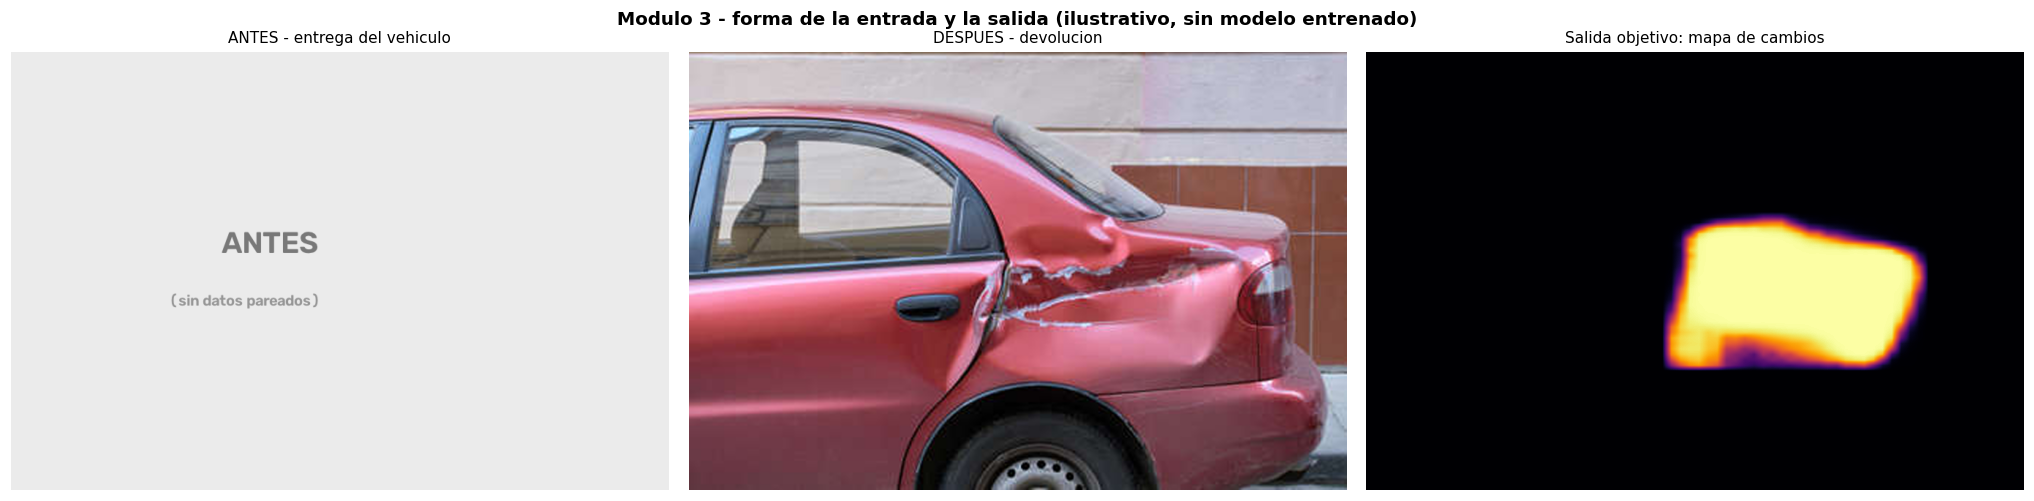

*El mapa de la derecha proviene del detector supervisado del Modulo 2b, no del Modulo 3. Se muestra para ilustrar la **forma** de la salida esperada: una mascara continua de confianza sobre la region modificada.*

In [13]:
# Ilustracion de la entrada y la salida esperadas del Modulo 3.
# El panel "ANTES" es un marcador de posicion: no existe todavia la contraparte sin dano
# de esta unidad, y esa ausencia de datos pareados es el bloqueo principal del modulo.
antes = np.full_like(imagen_a, 235)
cv2.putText(antes, "ANTES", (int(antes.shape[1] * 0.32), int(antes.shape[0] * 0.46)),
            cv2.FONT_HERSHEY_SIMPLEX, 1.4, (120, 120, 120), 3, cv2.LINE_AA)
cv2.putText(antes, "(sin datos pareados)", (int(antes.shape[1] * 0.24), int(antes.shape[0] * 0.58)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (150, 150, 150), 2, cv2.LINE_AA)

# La salida objetivo tiene la forma de un mapa de cambios; aqui se ilustra con la mascara
# que el detector supervisado ya produce, NO con una prediccion del Modulo 3.
mapa_cambios = np.zeros(imagen_a.shape[:2], dtype=np.float32)
if danos_a["masks"] is not None and len(danos_a["masks"]):
    for mascara, score in zip(danos_a["masks"], danos_a["scores"]):
        mapa_cambios = np.maximum(mapa_cambios, mascara[0] * float(score))

show([("ANTES - entrega del vehiculo", antes),
      ("DESPUES - devolucion", imagen_a),
      ("Salida objetivo: mapa de cambios", (mapa_cambios * 255).astype(np.uint8))],
     title="Modulo 3 - forma de la entrada y la salida (ilustrativo, sin modelo entrenado)")

display(Markdown(
    "*El mapa de la derecha proviene del detector supervisado del Modulo 2b, no del "
    "Modulo 3. Se muestra para ilustrar la **forma** de la salida esperada: una mascara "
    "continua de confianza sobre la region modificada.*"
))

---
# Resumen del avance

| # | Módulo | Estado | Evidencia en este notebook |
|---|---|---|---|
| 1 | Preprocesamiento óptico | Implementado, **no integrado** | CLAHE opera correctamente; la supresión de reflejos aún degrada superficies difusas oscuras |
| 2 | Segmentación de componentes | Entrenado, **limitado fuera de dominio** | Funciona en vehículo completo (Caso B), falla en acercamiento (Caso A) |
| 2b | Detección de daños | **Entrenado y funcional** | `dent` con confianza 1.00 y máscara precisa (Caso A) |
| — | Integración entre módulos | **Mecanismo resuelto** | Tabla de cruce daño → componente operativa en ambos casos |
| 3 | Detección de cambios | **Pendiente** | Arquitectura definida; bloqueado por ausencia de datos pareados |

### Siguientes pasos, en orden de prioridad

1. **Reentrenar el Módulo 2** con más datos de vehículos en entorno real y el aumento de
   datos ya implementado. Es lo que hoy limita la calidad del reporte final.
2. **Inferencia en mosaico** para el detector de daños, para recuperar desempeño en tomas
   de vehículo completo sin exigir fotografías adicionales al usuario.
3. **Definir el protocolo de captura** de la aplicación a partir del hallazgo de
   encuadres opuestos.
4. **Construir el conjunto de datos pareados** antes/después, requisito para iniciar el
   Módulo 3.